## Plot mean of each cluster, for all clusters: wind speed and direction
Fig 4

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import math
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
from matplotlib import rcParams
import matplotlib
import ast

ERROR 1: PROJ: proj_create_from_database: Cannot find proj.db


In [2]:
rcParams['font.size'] = 20

In [3]:
#output file location
input_table_loc = '/div/nac/users/zofias/plots/XXN/prect_6_clim/single'
out_plots = '/div/nac/users/zofias/plots/XXN/paper_plots'

input_fileloc = '/div/no-backup-nac/users/zofias/CESM2-LENS/weather_data/7cluster_background'

group_label = '7_cluster_events'

var_name='?850'

# %%
# select region by changing region_label
region_label = 'NO_ext' #sys.argv[3] #'EU' # 'SA' 'EA' 'NA' 'EU'

regions = {'SA': [5,35,65,95],
           'EA' : [20,53,95,133],
           'NA' : [25,70,-150,-45],
           'EU' : [35,70,-20,45],
           'NO' : [53,72,0,32],
           'NO_ext': [50,75,-25,32]}

#selects lat lon bounds for region
lat_min, lat_max, lon_min, lon_max = regions[region_label]


In [4]:
locs_dataframe = pd.read_csv(f'{input_table_loc}/grouped_events_table.csv',index_col=0)

In [5]:
#extract member columns from filename
locs_dataframe['member_ind'] = pd.to_numeric(locs_dataframe['ens_member'].str[1:]) - 1

# read in disctionary of mapping from ensemble index to label
with open('/div/nac/users/zofias/XXN/ens_member_labs_dict.txt', 'r') as file:
    test = file.read()
    ens_dict = ast.literal_eval(test)

# map member index to label
locs_dataframe['member_lab'] = locs_dataframe['member_ind'].map(ens_dict)

#make column with correct dacade lab for file download
year_labs = ['20150101-20241231.nc','20250101-20341231.nc','20350101-20441231.nc','20450101-20541231.nc','20550101-20641231.nc','20650101-20741231.nc','20750101-20841231.nc','20850101-20941231.nc','20950101-21001231.nc']
bins = [2015, 2024, 2034, 2044, 2054, 2064, 2074, 2084, 2094,2101]
labels = year_labs
locs_dataframe['decade_lab'] = pd.cut(locs_dataframe.year, bins, labels = labels,include_lowest = True)

# make column with precip filename
locs_dataframe['lensfile'] = locs_dataframe.apply(lambda x: f"b.e21.BSSP370smbb.f09_g17.LE2-{x.member_lab}.cam.h1.{var_name}.{x.decade_lab}", axis=1)
locs_dataframe['lensfile_psl'] = locs_dataframe.apply(lambda x: f"b.e21.BSSP370smbb.f09_g17.LE2-{x.member_lab}.cam.h1.PSL.{x.decade_lab}", axis=1)

In [6]:
#define dates for selecting data (14 days before up to 3 days after)
locs_dataframe['start_date'] = (pd.to_datetime(locs_dataframe['date']) - pd.to_timedelta(14,'d')).dt.strftime("%Y-%m-%d") 
locs_dataframe['end_date'] = (pd.to_datetime(locs_dataframe['date']) + pd.to_timedelta(3,'d')).dt.strftime("%Y-%m-%d")

In [7]:
#make lat and lon bins over select region (for selecting 9 gridboxes for each event)
# got event lat and lons from CESM2LENS nc file, lats have loads of decimals so rounded to 2dp here (same as in selection below)
lon_bins = [-25.,-23.75,-22.5,-21.25,-20.,-18.75,-17.5,-16.25,-15.,-13.75,-12.5,-11.25,-10.,-8.75,-7.5,-6.25,-5.,-3.75,-2.5 ,-1.25,0.,1.25,2.5,3.75,5.,6.25,7.5,8.75,10.,11.25,12.5,13.75,15.,16.25,17.5,18.75,20.,21.25,22.5,23.75,25.,26.25,27.5,28.75,30.,31.25]
locs_dataframe['lon_bin'] = pd.cut(locs_dataframe.lon, lon_bins, labels = lon_bins[:-1],include_lowest = True)
locs_dataframe['lon_min'] = locs_dataframe.lon_bin.apply(lambda x: x - 1.25)
locs_dataframe['lon_max'] = locs_dataframe.lon_bin.apply(lambda x: x + 1.25)

lat_bins = [49.48,  50.42,  51.36,  52.3 ,
        53.25,  54.19,  55.13,  56.07,  57.02,  57.96,  58.9 ,  59.84,
        60.79,  61.73,  62.67,  63.61,  64.55,  65.5 ,  66.44,  67.38,
        68.32,  69.27,  70.21,  71.15,  72.09,  73.04,  73.98,  74.92,
        75.86,  76.81,  77.75,  78.69,  79.63] #one extra on either end for making min and max

locs_dataframe['lat_bin'] = pd.cut(locs_dataframe.lat, lat_bins[1:-1],labels=lat_bins[1:-2],include_lowest = True)
locs_dataframe['lat_min'] = pd.cut(locs_dataframe.lat, lat_bins[1:-1],labels=lat_bins[0:-3],include_lowest = True)
locs_dataframe['lat_max'] = pd.cut(locs_dataframe.lat, lat_bins[1:-1],labels=lat_bins[2:-1],include_lowest = True)

In [8]:
# build concatenated dataset for each cluster
def load_cluster_events(cluster_df):
    event_datasets = []

    for i, row in cluster_df.reset_index(drop=True).iterrows():
        print(f"Processing {i+1} of {len(cluster_df)}")
        #print(row["start_date"])

        ds = xr.open_mfdataset(f"{input_fileloc}/{row['lensfile']}",
                             decode_times=True).sel(time=slice(row["start_date"], row["end_date"]))
        
        ds = ds.drop_vars("time_bnds", errors="ignore")

        #reset lon coord
        ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby("lon")
        #select region
        ds = ds.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))

        #reindex time to be -14 to 3 for all events (some have 17 time steps, some have 18)
        n = ds.sizes["time"]                       # can be 17 or 18
        ds = ds.assign_coords(time=np.arange(-14, -14 + n))
        ds = ds.reindex(time=np.arange(-14, 4)) 

        event_datasets.append(ds[['U850','V850']])

    # member = event index within this cluster
    return xr.concat(event_datasets, dim="member")

In [9]:
# build concatenated dataset for each cluster
def load_cluster_events_psl(cluster_df,var):
    event_datasets = []

    for i, row in cluster_df.reset_index(drop=True).iterrows():
        print(f"Processing {i+1} of {len(cluster_df)}")
        #print(row["start_date"])

        ds = xr.open_dataset(f"{input_fileloc}/{row['lensfile_psl']}",
                             decode_times=True).sel(time=slice(row["start_date"], row["end_date"]))
        
        ds = ds.drop_vars("time_bnds", errors="ignore")

        #reset lon coord
        ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby("lon")
        #select region
        ds = ds.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))

        #reindex time to be -14 to 3 for all events (some have 17 time steps, some have 18)
        n = ds.sizes["time"]                       # can be 17 or 18
        ds = ds.assign_coords(time=np.arange(-14, -14 + n))
        ds = ds.reindex(time=np.arange(-14, 4)) 

        event_datasets.append(ds[{var}])

    # member = event index within this cluster
    return xr.concat(event_datasets, dim="member")

In [10]:
#make dictionary for all cluster datasets
cluster_data = {}  

for g in range(7):
    print(f'Processing cluster {g+1} of 7')
    cluster_df = locs_dataframe[locs_dataframe["group"] == g][:8]
    cluster_data[g] = load_cluster_events(cluster_df)

Processing cluster 1 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 2 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 3 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 4 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 5 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 6 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 

In [11]:
#make dictionary for all cluster datasets
cluster_data_psl = {}  

for g in range(7):
    print(f'Processing cluster {g+1} of 7')
    cluster_df = locs_dataframe[locs_dataframe["group"] == g][:8]
    cluster_data_psl[g] = load_cluster_events_psl(cluster_df,'PSL')

Processing cluster 1 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 2 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 3 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 4 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 5 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 6 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 

### Plot wind on event day

/scratch/tmp/ipykernel_654268/2110276463.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1)


Text(0.07, 0.225, 'Wind speed at 850 hPa (m/s)')

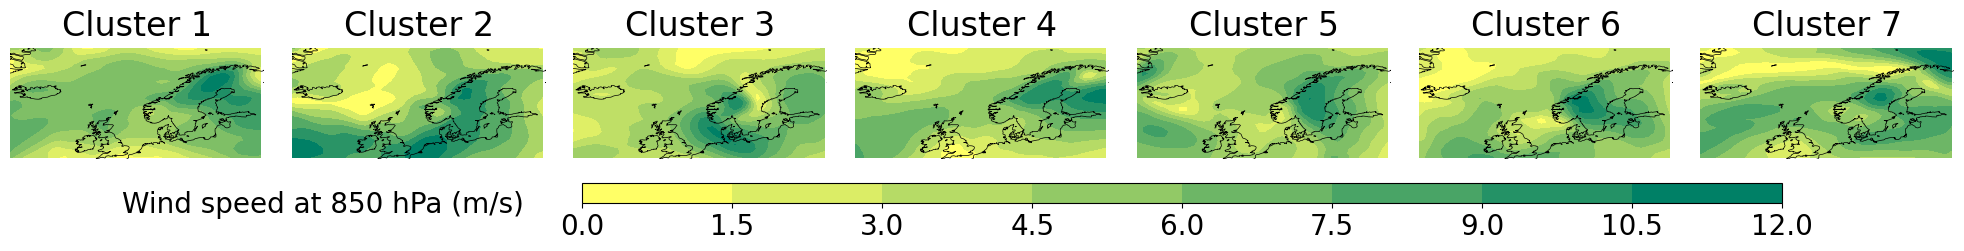

In [19]:
fig, axs = plt.subplots(nrows=1,ncols=len(cluster_data),
                        subplot_kw={'projection': ccrs.PlateCarree(),'frameon':False},
                        figsize=(20,4),
                        frameon=False
                        )

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()

#Loop over all of the models
for n,time in enumerate(cluster_data):
    u = cluster_data[n].U850.isel(time=14).mean(dim='member')
    v = cluster_data[n].V850.isel(time=14).mean(dim='member')
    wind_speed = np.sqrt(u**2 + v**2)
    
    fg =  wind_speed.plot.contourf(ax=axs[n],cmap='summer_r',
                                   add_colorbar=False,
                                   levels=10,#,norm=norm, #
                                                #vmax=0, vmin=90, 
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    axs[n].coastlines(linewidth=0.5)  # cartopy function
    axs[n].set_title(f'Cluster {n+1}',y=1.03)
    #fg2.clabel(fontsize=9, inline=1, fmt='%.0f')


cbar_ax = fig.add_axes([0.3, 0.25, 0.6, 0.05])
cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='')
#cbar.set_ticks(np.arange(-0.16,0.17,0.04))
#cbar_ax = fig.add_axes([0.2, 0.47, 0.6, 0.015])
#cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Precip (mm/day)')
#plt.suptitle(f'Locations of grouped {exp_label} extremes',y=0.88)
#fig.subplots_adjust(bottom=0.5, top=0.9, left=0.1, right=0.9,wspace=0.02, hspace=0.17)
plt.tight_layout(pad=1)
fig.text(0.07,0.225,f'Wind speed at 850 hPa (m/s)')

/scratch/tmp/ipykernel_654268/835893095.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.5)


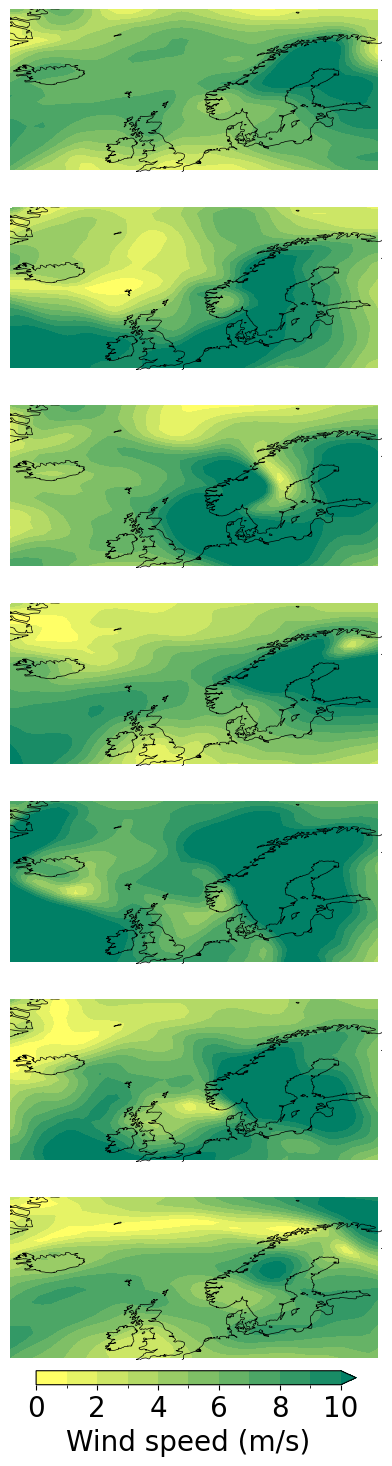

In [16]:
fig, axs = plt.subplots(nrows=len(cluster_data),ncols=1,
                        subplot_kw={'projection': ccrs.PlateCarree(),'frameon':False},
                        figsize=(4,14),
                        frameon=False
                        )

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()

#Loop over all of the models
for n,time in enumerate(cluster_data):
    u = cluster_data[n].U850.isel(time=14).mean(dim='member')
    v = cluster_data[n].V850.isel(time=14).mean(dim='member')
    wind_speed = np.sqrt(u**2 + v**2)
    
    fg =  wind_speed.plot.contourf(ax=axs[n],cmap='summer_r',
                                   add_colorbar=False,
                                   levels=11,#,norm=norm, #
                                    vmax=10, vmin=0, 
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    axs[n].coastlines(linewidth=0.5)  # cartopy function
    axs[n].set_title('')#(f'Cluster {n+1}',y=1.03)
    #fg2.clabel(fontsize=9, inline=1, fmt='%.0f')

cbar_ax = fig.add_axes([0.1, 0.0, 0.8, 0.01])
cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Wind speed (m/s)')
cbar.set_ticks(np.arange(0,11,2))
#cbar_ax = fig.add_axes([0.2, 0.47, 0.6, 0.015])
#cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Precip (mm/day)')
#plt.suptitle(f'Locations of grouped {exp_label} extremes',y=0.88)
#fig.subplots_adjust(bottom=0.5, top=0.9, left=0.1, right=0.9,wspace=0.02, hspace=0.17)
plt.tight_layout(pad=0.5)
#fig.text(0.03,0.225,f'Wind speed at 850 hPa (m/s)')

In [22]:
cluster_data_psl[0].PSL

<xarray.DataArray 'PSL' (member: 8, time: 18, lat: 27, lon: 46)>
array([[[[102945.5  , 102982.79 , 103007.414, ..., 101532.04 ,
          101455.27 , 101379.59 ],
         [102888.98 , 102939.64 , 102978.21 , ..., 101433.08 ,
          101362.55 , 101297.29 ],
         [102819.734, 102879.195, 102929.195, ..., 101312.41 ,
          101237.62 , 101171.836],
         ...,
         [100604.555, 100812.25 , 100921.46 , ..., 101690.414,
          101616.68 , 101542.68 ],
         [100645.375, 100822.29 , 100849.22 , ..., 101824.586,
          101770.13 , 101704.27 ],
         [100555.59 , 100757.66 , 100749.78 , ..., 101975.836,
          101930.72 , 101881.83 ]],

        [[102618.59 , 102656.91 , 102691.695, ..., 101652.305,
          101600.55 , 101543.11 ],
         [102479.44 , 102524.945, 102568.22 , ..., 101596.26 ,
          101537.68 , 101483.914],
         [102386.125, 102418.93 , 102453.04 , ..., 101515.36 ,
          101459.29 , 101402.85 ],
...
         [100971.09 , 100981.8  , 100970.   , ..., 100477.35 ,
          100488.31 , 100481.92 ],
         [101028.23 , 101051.3  , 101077.15 , ..., 100566.99 ,
          100561.016, 100534.836],
         [100911.89 , 101013.75 , 101134.29 , ..., 100636.195,
          100598.03 , 100552.3  ]],

        [[ 99915.164, 100034.69 , 100176.45 , ..., 103015.875,
          102945.92 , 102884.125],
         [ 99922.49 , 100024.34 , 100142.555, ..., 102914.31 ,
          102854.1  , 102793.25 ],
         [ 99959.53 , 100039.55 , 100139.08 , ..., 102843.73 ,
          102779.87 , 102711.03 ],
         ...,
         [101042.45 , 101039.39 , 101012.07 , ...,  99314.8  ,
           99372.766,  99433.125],
         [100995.73 , 101076.945, 101086.445, ...,  99577.42 ,
           99618.69 ,  99660.31 ],
         [100806.87 , 100923.32 , 101073.164, ...,  99824.74 ,
           99848.5  ,  99866.055]]]], dtype=float32)
Coordinates:
  * lat      (lat) float64 50.42 51.36 52.3 53.25 ... 72.09 73.04 73.98 74.92
  * lon      (lon) float64 -25.0 -23.75 -22.5 -21.25 ... 27.5 28.75 30.0 31.25
  * time     (time) int64 -14 -13 -12 -11 -10 -9 -8 -7 -6 -5 -4 -3 -2 -1 0 1 2 3
Dimensions without coordinates: member
Attributes:
    units:         Pa
    long_name:     Sea level pressure
    cell_methods:  time: mean

IndexError: index 6 is out of bounds for axis 0 with size 6

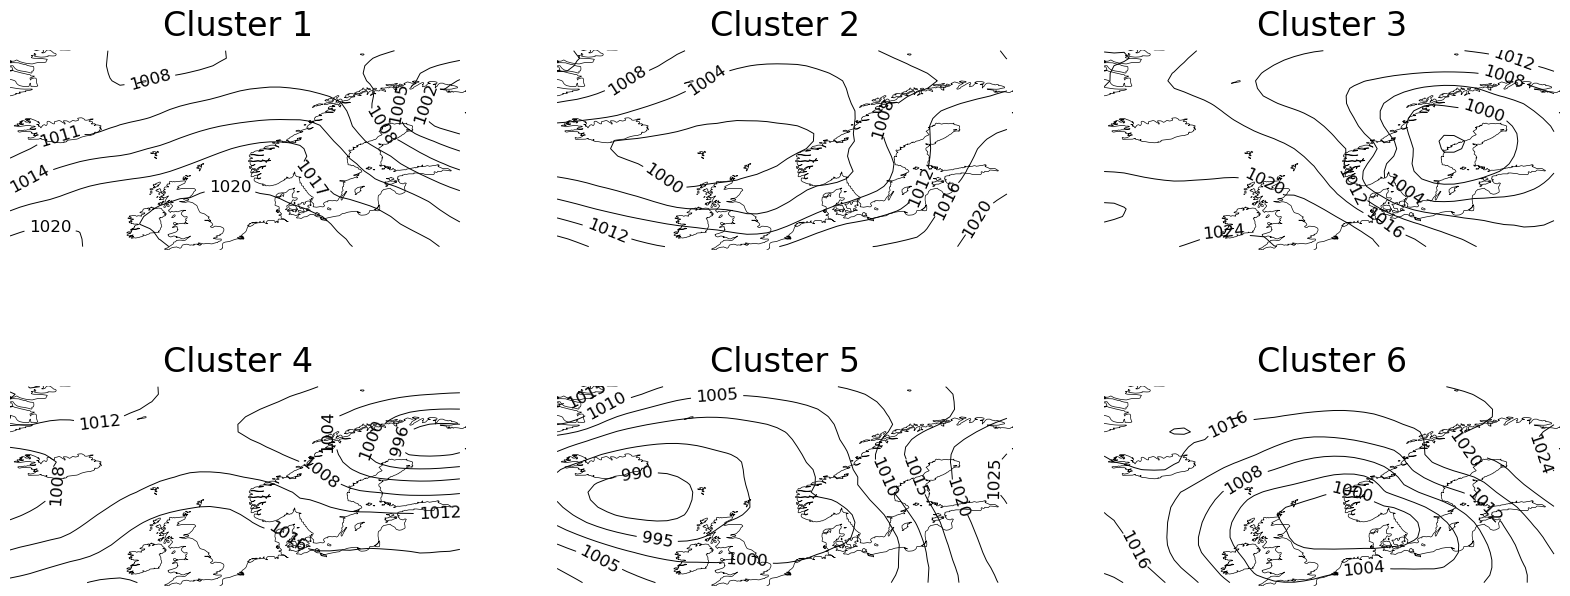

In [34]:
fig, axs = plt.subplots(nrows=2,ncols=len(cluster_data)//2,
                        subplot_kw={'projection': ccrs.PlateCarree(),'frameon':False},
                        figsize=(20,8),
                        frameon=False
                        )

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()

#Loop over all of the models
for n,time in enumerate(cluster_data):

    fg2 = (cluster_data_psl[n].PSL.isel(time=14).sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max)).mean(dim='member')/100).plot.contour(ax=axs[n],
                                                             #vmax=1020, vmin=980,
                                                             levels=9,#
                                                             xlim=(lon_min,lon_max),
                                                             ylim=(lat_min,lat_max),
                                                             colors='k',
                                                             linewidths=0.7
                                                             )
    
    axs[n].coastlines(linewidth=0.5)  # cartopy function
    axs[n].set_title(f'Cluster {n+1}',y=1.03)
    fg2.clabel(fontsize=12, inline=1, fmt='%.0f')

#cbar_ax = fig.add_axes([0.2, 0.25, 0.6, 0.03])
#cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Wind speed at 850 hPa (m/s)')
#cbar.set_ticks(np.arange(-0.16,0.17,0.04))
#cbar_ax = fig.add_axes([0.2, 0.47, 0.6, 0.015])
#cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Precip (mm/day)')
#plt.suptitle(f'Locations of grouped {exp_label} extremes',y=0.88)
#fig.subplots_adjust(bottom=0.5, top=0.9, left=0.1, right=0.9,wspace=0.02, hspace=0.17)
plt.tight_layout(pad=1)

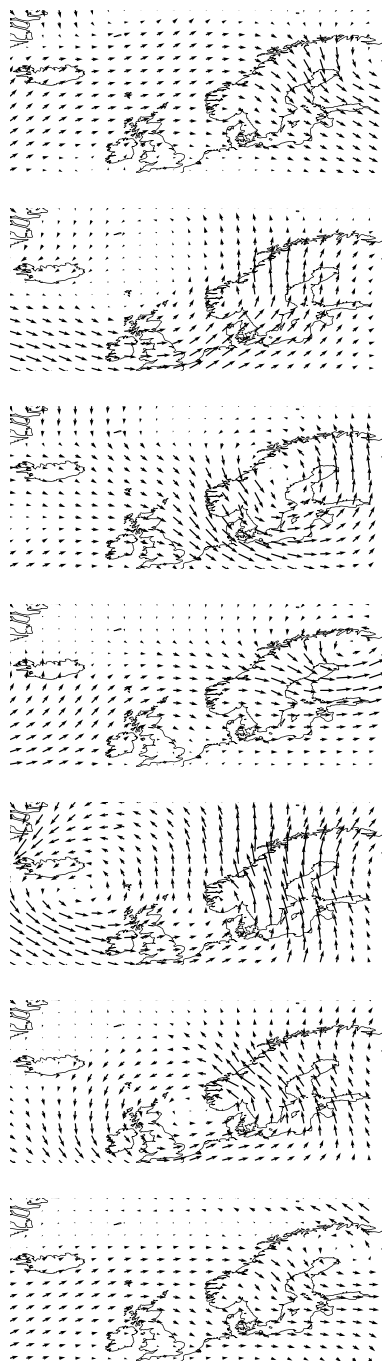

In [21]:
fig, axs = plt.subplots(nrows=7,ncols=1,
                        subplot_kw={'projection': ccrs.PlateCarree(),'frameon':False},
                        figsize=(4,14),
                        frameon=False
                        )

lons = cluster_data[0].lon
lats = cluster_data[0].lat

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()

#Loop over all of the models
for n,time in enumerate(cluster_data):
    u = cluster_data[n].U850.isel(time=14).mean(dim='member').squeeze()
    v = cluster_data[n].V850.isel(time=14).mean(dim='member').squeeze()

    fg = axs[n].quiver(lons[::2], lats[::2], u[::2, ::2], v[::2, ::2], scale=300)
    
    axs[n].set_xlim(lon_min,lon_max)
    axs[n].set_ylim(lat_min,lat_max)
    axs[n].coastlines(linewidth=0.5)  # cartopy function
    axs[n].set_title('')#(f'Cluster {n+1}',y=1.03)


#cbar_ax = fig.add_axes([0.2, 0.25, 0.6, 0.03])
#cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Wind direction at 850 hPa')
plt.tight_layout(pad=0.5)